In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("./data/combined_data.csv")
print(df)

       label                                               text
0          1  ounce feather bowl hummingbird opec moment ala...
1          1  wulvob get your medircations online qnb ikud v...
2          0   computer connection from cnn com wednesday es...
3          1  university degree obtain a prosperous future m...
4          0  thanks for all your answers guys i know i shou...
...      ...                                                ...
83443      0  hi given a date how do i get the last date of ...
83444      1  now you can order software on cd or download i...
83445      1  dear valued member canadianpharmacy provides a...
83446      0  subscribe change profile contact us long term ...
83447      1  get the most out of life ! viagra has helped m...

[83448 rows x 2 columns]


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [4]:
df_one = df[df['label']==1]
print(df_one.head())

   label                                               text
0      1  ounce feather bowl hummingbird opec moment ala...
1      1  wulvob get your medircations online qnb ikud v...
3      1  university degree obtain a prosperous future m...
8      1  works gateway world art explore tattooing full...
9      1  upon this account he is not only very cautious...


In [5]:
#'1' indicates that the email is classified as spam.
#'0' denotes that the email is legitimate (ham).
df['label'].value_counts()

label
1    43910
0    39538
Name: count, dtype: int64

In [6]:
#see percentage 
df['label'].value_counts(normalize=True)

label
1    0.526196
0    0.473804
Name: proportion, dtype: float64

<Axes: xlabel='label'>

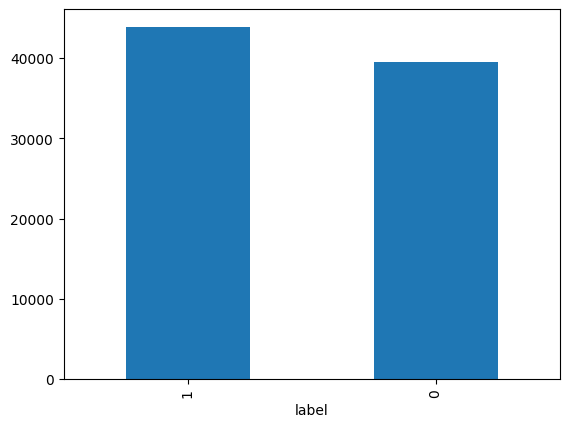

In [7]:
df['label'].value_counts().plot(kind='bar')


In [8]:
import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
custom_stopwords = stop_words.union({'http', 'https', 'www', 'com', 'net', 'org', 'html', 'escapenumber', 'escapelong', 'one', 'us', 'get', 'please', 'see', 'time', 'like', 'may', 'new'})

url_pattern = r'https?://\S+|www\.\S+|\b\w+(?:[-.]\w+)*\.(?:com|net|org|edu|gov|io|co|uk|ng|info|biz)\S*'

def clean_message(text):
    text = str(text).lower()
    text = re.sub(url_pattern, ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in custom_stopwords]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_message)
spam = df.loc[df['label'] == 1, 'clean_text']
non_spam = df.loc[df['label'] == 0, 'clean_text']

KeyboardInterrupt: 

In [ ]:
vectorizer = TfidfVectorizer(stop_words=list(custom_stopwords), max_features=50)

In [ ]:
tfidf_spam = vectorizer.fit_transform(spam)
spam_words = vectorizer.get_feature_names_out()
spam_scores = tfidf_spam.sum(axis=0).A1

spam_ranking = sorted(list(zip(spam_words, spam_scores)), key=lambda x: x[1], reverse=True)
spam_ranking[:15]

[('price', np.float64(2765.6221382651142)),
 ('email', np.float64(2388.993722516551)),
 ('day', np.float64(2339.1106106321245)),
 ('best', np.float64(2313.2239127059747)),
 ('quality', np.float64(2095.400695419229)),
 ('money', np.float64(2042.8437613237713)),
 ('online', np.float64(2036.620618211508)),
 ('free', np.float64(2007.037314653003)),
 ('company', np.float64(1994.8546081796806)),
 ('want', np.float64(1978.7483543303676)),
 ('would', np.float64(1917.549764700723)),
 ('click', np.float64(1913.9378128154335)),
 ('information', np.float64(1806.404675885925)),
 ('news', np.float64(1783.6459991068582)),
 ('need', np.float64(1721.5231910401533))]

In [ ]:
tfidf_non = vectorizer.fit_transform(non_spam)
non_words = vectorizer.get_feature_names_out()
non_scores = tfidf_non.sum(axis=0).A1

non_ranking = sorted(list(zip(non_words, non_scores)), key=lambda x: x[1], reverse=True)
non_ranking[:15]

[('enron', np.float64(3814.9246493686906)),
 ('would', np.float64(2952.8405190791104)),
 ('help', np.float64(2948.3812229712116)),
 ('list', np.float64(2707.840498755048)),
 ('thanks', np.float64(2552.9716645592644)),
 ('file', np.float64(2396.4117152225376)),
 ('wrote', np.float64(2286.159271536525)),
 ('know', np.float64(2281.2513666221985)),
 ('perl', np.float64(2262.6805939864)),
 ('subject', np.float64(2227.8681849206832)),
 ('email', np.float64(2130.7464381147993)),
 ('mail', np.float64(2126.4582938949166)),
 ('stat', np.float64(2074.3314425871968)),
 ('ch', np.float64(2065.2892497394173)),
 ('ect', np.float64(2045.0948916028526))]

In [ ]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [ ]:
import re

# Example: assume your dataset column is called 'text'
df['text'] = df['text'].apply(lambda x: re.sub(r'http\S+|www\S+', '', x))

In [ ]:
import pandas as pd
import re

# Define unwanted words
unwanted = ["escapenumber", "escapelong"]

# Build regex pattern from unwanted list
pattern = r'\b(?:' + '|'.join(unwanted) + r')\b'

# Apply cleaning
df['text'] = df['text'].apply(lambda x: re.sub(pattern, '', str(x)))

# Optional: remove extra spaces left behind
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

print(df)

       label                                               text  \
0          1  ounce feather bowl hummingbird opec moment ala...   
1          1  wulvob get medircations online qnb ikud viagra...   
2          0  computer connection cnn com wednesday may pm e...   
3          1  university degree obtain prosperous future mon...   
4          0  thanks answers guys know checked rsync manual ...   
...      ...                                                ...   
83443      0  hi given date get last date month data form yy...   
83444      1  order software cd download site immediately de...   
83445      1  dear valued member canadianpharmacy provides w...   
83446      0  subscribe change profile contact us long term ...   
83447      1  get life viagra helped millions men good cause...   

                                              clean_text  
0      ounce feather bowl hummingbird opec moment ala...  
1      wulvob get medircations online qnb ikud viagra...  
2      computer co

In [ ]:
import re
import string
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_message(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'\d+', '', text)                  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'[^a-z\s]', '', text)             # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()         # remove extra spaces
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

# IMPORTANT: only clean the text column, not the label
df['clean_text'] = df['text'].apply(clean_message)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wizbi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def clean_message(text):
    text = str(text).lower()
    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # remove standalone 'http' or 'www'
    text = re.sub(r'\bhttp\b|\bwww\b', '', text)
    # remove numbers
    text = re.sub(r'\d+', '', text)
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # remove special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # filter stopwords + custom tokens
    custom_stopwords = stop_words.union({'http','www'})
    words = [w for w in text.split() if w not in custom_stopwords]
    return " ".join(words)


In [ ]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


def clean_message(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove special characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def filter_message(text, min_length=3):
    # Tokenize
    words = text.split()
    # Remove stopwords
    words = [w for w in words if w not in stop_words]
    # Rule 1: too short
    if len(words) < min_length:
        return None
    # Rule 2: meaningless (e.g., all words are junk or repeated nonsense)
    if all(len(w) <= 2 for w in words):  # crude heuristic
        return None
    return " ".join(words)

# Apply cleaning + filtering
df['text'] = df['text'].apply(clean_message)
df['text'] = df['text'].apply(lambda x: filter_message(x))

# Drop rows that became None
df = df.dropna()

print(df)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wizbi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


       label                                               text  \
0          1  ounce feather bowl hummingbird opec moment ala...   
1          1  wulvob get medircations online qnb ikud viagra...   
2          0  computer connection cnn com wednesday may pm e...   
3          1  university degree obtain prosperous future mon...   
4          0  thanks answers guys know checked rsync manual ...   
...      ...                                                ...   
83443      0  hi given date get last date month data form yy...   
83444      1  order software cd download site immediately de...   
83445      1  dear valued member canadianpharmacy provides w...   
83446      0  subscribe change profile contact us long term ...   
83447      1  get life viagra helped millions men good cause...   

                                              clean_text  
0      ounce feather bowl hummingbird opec moment ala...  
1      wulvob get medircations online qnb ikud viagra...  
2      computer co

In [ ]:
text = "Check this out http://www.example.com for details"
tokens = text.split()  # now you have a list of words

In [ ]:
stopwords = {"http", "https", "www", "com"}
tokens = [t for t in tokens if t.lower() not in stopwords]
print(tokens)

['Check', 'this', 'out', 'http://www.example.com', 'for', 'details']


In [ ]:
import re

text = re.sub(r'http\S+|www\.\S+', '', text)  # remove URLs
tokens = text.split()
stopwords = {"http", "https", "www", "com"}
tokens = [t for t in tokens if t.lower() not in stopwords]

In [ ]:
# Check the TF-IDF vocabulary after fitting the vectorizer.
print(vectorizer.get_feature_names_out())

['also' 'branches' 'ch' 'code' 'company' 'ctdb' 'data' 'ect' 'enron'
 'escapenumberd' 'ethz' 'file' 'get' 'guide' 'help' 'hou' 'know' 'like'
 'list' 'listinfo' 'mail' 'mailing' 'mailman' 'may' 'message' 'name'
 'need' 'new' 'news' 'one' 'perl' 'please' 'pm' 'posting' 'project'
 'provide' 'read' 'said' 'samba' 'self' 'source' 'stat' 'struct' 'subject'
 'thanks' 'time' 'us' 'use' 'would' 'wrote']


In [ ]:
print(df.columns)

Index(['label', 'text', 'clean_text'], dtype='object')


In [ ]:
df.head(5)

,label,text,clean_text
0,1,ounce feather bowl hummingbird opec moment ala...,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday may pm e...,computer connection cnn com wednesday may pm e...
3,1,university degree obtain prosperous future mon...,university degree obtain prosperous future mon...
4,0,thanks answers guys know checked rsync manual ...,thanks answers guys know checked rsync manual ...
